<a href="https://colab.research.google.com/github/aldesqitanglx-spec/my-first-repo/blob/main/Salinan_dari_STIK4481_Aldes_Qitang_H_Tugas_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Tahap 1: Load Dataset

# 1. Impor library yang diperlukan
import pandas as pd

# 2. Baca file dataset_tugas1_preprocessing.csv ke dalam DataFrame
df = pd.read_csv("dataset_tugas1_preprocessing.csv")

# Menampilkan 5 baris pertama
df.head()

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0


In [ ]:
# Tahap 2: Eksplorasi Awal (EDA)

# 1. Cek struktur dan tipe data
print("Struktur dan Tipe Data")
df.info()

# 2. Tampilkan jumlah nilai hilang per kolom
print("\nJumlah Nilai Hilang per Kolom")
print(df.isnull().sum())

# 3. Sajikan statistik deskriptif
print("\nStatistik Deskriptif")
print(df.describe(include="all"))

Struktur dan Tipe Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB

Jumlah Nilai Hilang per Kolom
ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64

Statistik Deskriptif
           ID Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
count      99   99            99               99     99          70   
unique     99

In [ ]:
# Tahap 3: Menangani Missing Values

# Imputasi Nilai_Akhir dengan modus
df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(df['Nilai_Akhir'].mode()[0])

# Imputasi Umur dengan median
df['Umur'] = df['Umur'].fillna(df['Umur'].median())

# Mengecek kembali jumlah nilai yang hilang
print("Jumlah nilai hilang setelah imputasi:")
print(df.isnull().sum())

Jumlah nilai hilang setelah imputasi:
ID               0
Nama             0
Jenis_Kelamin    0
Prodi            0
Status           0
Nilai_Akhir      0
Tanggal_Ujian    0
Umur             0
dtype: int64


In [ ]:
# Tahap 4: Standarisasi Format Tanggal

# Mengonversi format kolom Tanggal_Ujian menjadi Datetime
df['Tanggal_Ujian'] = pd.to_datetime(df['Tanggal_Ujian'], format='mixed')

#Menampilkan hasil
print("Data setelah standarisasi:")
print(df.head())

Data setelah standarisasi:
      ID  Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
0  MH001  Iwan     Laki-laki  Teknik Komputer  Aktif           C   
1  MH002   Eka     Perempuan  Teknik Komputer  Lulus           E   
2  MH003  Iwan     Laki-laki  Teknik Komputer  Aktif           C   
3  MH004   Eka     Perempuan  Teknik Komputer  Aktif           D   
4  MH005  Joko     Perempuan     Data Science  Aktif           C   

  Tanggal_Ujian  Umur  
0    2020-04-13  23.0  
1    2020-12-11  28.0  
2    2021-11-21  23.0  
3    2021-08-19  18.0  
4    2020-01-05  26.0  


In [ ]:
# Tahap 5: Encoding Label

# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Kolom kategorikal yang akan di-encode
kolom_kategorikal = [
    'Nama',
    'Jenis_Kelamin',
    'Prodi',
    'Status',
    'Nilai_Akhir'
]

# Melakukan Label Encoding
for kolom in kolom_kategorikal:
    label_encoder = LabelEncoder()
    df[kolom] = label_encoder.fit_transform(df[kolom])

# Menampilkan hasil
print("Hasil setelah Label Encoding:")
print(df.head())

print("\nTipe data setelah encoding:")
print(df.dtypes)

Hasil setelah Label Encoding:
      ID  Nama  Jenis_Kelamin  Prodi  Status  Nilai_Akhir Tanggal_Ujian  Umur
0  MH001     8              0      3       0            2    2020-04-13  23.0
1  MH002     4              1      3       3            4    2020-12-11  28.0
2  MH003     8              0      3       0            2    2021-11-21  23.0
3  MH004     4              1      3       0            3    2021-08-19  18.0
4  MH005     9              1      0       0            2    2020-01-05  26.0

Tipe data setelah encoding:
ID                       object
Nama                      int64
Jenis_Kelamin             int64
Prodi                     int64
Status                    int64
Nilai_Akhir               int64
Tanggal_Ujian    datetime64[ns]
Umur                    float64
dtype: object


In [ ]:
# Tahap 6: Split Data

from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% data latih dan 20% data uji
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

# Menampilkan ukuran masing-masing data
print("Jumlah data awal :", len(df))
print("Jumlah data latih:", len(df_train))
print("Jumlah data uji  :", len(df_test))

Jumlah data awal : 99
Jumlah data latih: 79
Jumlah data uji  : 20


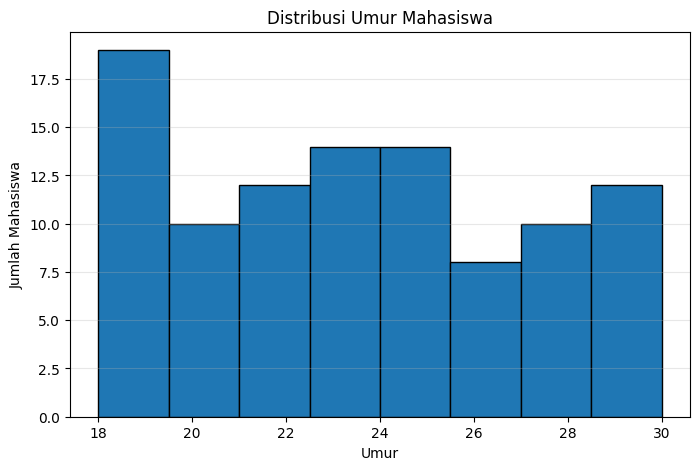

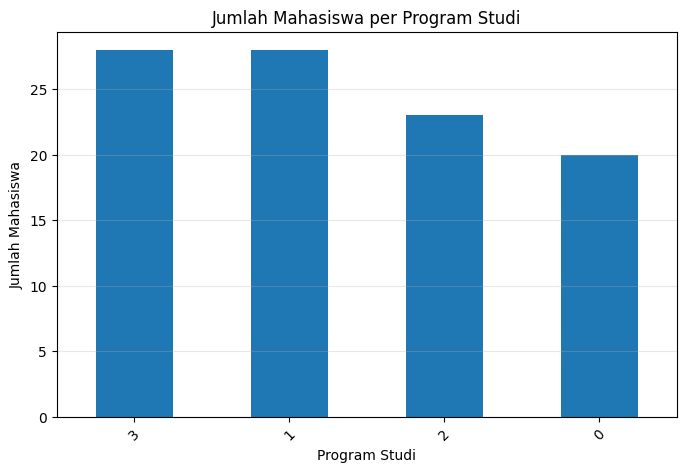

In [ ]:
# Tahap 7: Visualisasi

import matplotlib.pyplot as plt

# 1. Histogram Umur
plt.figure(figsize=(8, 5))
plt.hist(df['Umur'], bins=8, edgecolor='black')
plt.title('Distribusi Umur Mahasiswa')
plt.xlabel('Umur')
plt.ylabel('Jumlah Mahasiswa')
plt.grid(axis='y', alpha=0.3)
plt.show()


# 2. Grafik Batang Jumlah Mahasiswa per Prodi
jumlah_prodi = df['Prodi'].value_counts()

plt.figure(figsize=(8, 5))
jumlah_prodi.plot(kind='bar')
plt.title('Jumlah Mahasiswa per Program Studi')
plt.xlabel('Program Studi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()